# EDA: Distribution Check for Single Family Residential Sales

This notebook explores the distributions of `ClosePrice`, `LivingArea`, `Bedrooms`, `Bathrooms`, and `LotSize`.

Restrict the analysis to:

- `PropertyType = Residential`
- `PropertySubType = SingleFamilyResidence`

For `LotSize`, I use `LotSizeSquareFeet` because it is a numeric lot size field.


In [1]:
import pandas as pd
import numpy as np

## 1. Load the merged data

I only read the columns needed for this EDA


In [16]:
use_columns = [
    'PropertyType',
    'PropertySubType',
    'ClosePrice',
    'LivingArea',
    'BedroomsTotal',
    'BathroomsTotalInteger',
    'LotSizeSquareFeet'
]

data = pd.read_csv('../data/merged_crmls_sold.csv', usecols=use_columns, low_memory=False)

data.head()


,ClosePrice,PropertyType,LivingArea,PropertySubType,BathroomsTotalInteger,BedroomsTotal,LotSizeSquareFeet
0,95000.0,ManufacturedInPark,1368.0,NaN,2.0,2.0,NaN
1,1200.0,ResidentialLease,850.0,Apartment,1.0,2.0,43000.0
2,1100000.0,Residential,1344.0,Townhouse,3.0,3.0,NaN
3,2499999.0,Residential,2645.0,SingleFamilyResidence,4.0,4.0,13376.0
4,640000.0,Residential,1198.0,Townhouse,3.0,2.0,2738.0


In [17]:
print('Rows before filtering:', len(data))
print('Columns:', data.shape[1])


Rows before filtering: 794271
Columns: 7


## 2. Filter to the required property type

The analysis below only uses Residential and SingleFamilyResidence rows.


In [4]:
single_family = data[
    (data['PropertyType'] == 'Residential') &
    (data['PropertySubType'] == 'SingleFamilyResidence')
].copy()

print('Rows after filtering:', len(single_family))
single_family.head()


Rows after filtering: 399157


,ClosePrice,PropertyType,LivingArea,PropertySubType,BathroomsTotalInteger,BedroomsTotal,LotSizeSquareFeet
3,2499999.0,Residential,2645.0,SingleFamilyResidence,4.0,4.0,13376.0
6,640000.0,Residential,2070.0,SingleFamilyResidence,3.0,3.0,3397.0
7,438000.0,Residential,1174.0,SingleFamilyResidence,2.0,3.0,9900.0
12,615000.0,Residential,1996.0,SingleFamilyResidence,2.0,2.0,6098.0
14,399990.0,Residential,1422.0,SingleFamilyResidence,2.0,3.0,12197.0


## 3. Clean the numeric columns


- `BedroomsTotal` as Bedrooms
- `BathroomsTotalInteger` as Bathrooms
- `LotSizeSquareFeet` as LotSize


In [5]:
numeric_columns = [
    'ClosePrice',
    'LivingArea',
    'BedroomsTotal',
    'BathroomsTotalInteger',
    'LotSizeSquareFeet'
]

for column in numeric_columns:
    single_family[column] = pd.to_numeric(single_family[column], errors='coerce')

single_family = single_family.rename(columns={
    'BedroomsTotal': 'Bedrooms',
    'BathroomsTotalInteger': 'Bathrooms',
    'LotSizeSquareFeet': 'LotSize'
})

eda_columns = ['ClosePrice', 'LivingArea', 'Bedrooms', 'Bathrooms', 'LotSize']

single_family[eda_columns].head()


,ClosePrice,LivingArea,Bedrooms,Bathrooms,LotSize
3,2499999.0,2645.0,4.0,4.0,13376.0
6,640000.0,2070.0,3.0,3.0,3397.0
7,438000.0,1174.0,3.0,2.0,9900.0
12,615000.0,1996.0,2.0,2.0,6098.0
14,399990.0,1422.0,3.0,2.0,12197.0


## 4. Missing values

Before looking at distributions, I check how many missing values each variable has.


In [6]:
missing_values = single_family[eda_columns].isna().sum()
missing_percent = single_family[eda_columns].isna().mean() * 100

missing_table = pd.DataFrame({
    'missing_count': missing_values,
    'missing_percent': missing_percent
})

missing_table


,missing_count,missing_percent
ClosePrice,2,0.000501
LivingArea,210,0.052611
Bedrooms,0,0.000000
Bathrooms,75,0.018790
LotSize,6826,1.710104


## 5. Summary statistics

This table gives the basic distribution summary for each variable.


In [7]:
summary_table = single_family[eda_columns].describe().T
summary_table


,count,mean,std,min,25%,50%,75%,max
ClosePrice,399155.0,1.285092e+06,5.237207e+06,0.0,620000.0,889000.0,1425000.0,9.895000e+08
LivingArea,398947.0,2.036718e+03,3.803275e+03,0.0,1373.0,1800.0,2417.5,2.308680e+06
Bedrooms,399157.0,3.476710e+00,9.605173e-01,0.0,3.0,3.0,4.0,4.500000e+01
Bathrooms,399082.0,2.610133e+00,1.182700e+00,0.0,2.0,2.0,3.0,1.750000e+02
LotSize,392331.0,2.454994e+05,1.387443e+07,0.0,5663.0,7247.0,10340.0,2.087221e+09


## 6. Quantiles

Quantiles make it easier to see the typical range and high-end outliers.


In [8]:
quantile_table = single_family[eda_columns].quantile([
    0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99
]).T

quantile_table


,0.01,0.05,0.25,0.50,0.75,0.95,0.99
ClosePrice,235000.0,365000.0,620000.0,889000.0,1425000.0,3150000.0,6200000.0
LivingArea,725.0,960.0,1373.0,1800.0,2417.5,3801.0,5655.0
Bedrooms,2.0,2.0,3.0,3.0,4.0,5.0,6.0
Bathrooms,1.0,1.0,2.0,2.0,3.0,5.0,6.0
LotSize,1800.0,3250.0,5663.0,7247.0,10340.0,49478.5,258311.0


## 7. Skewness

Positive skewness means the distribution has a long right tail.


In [9]:
skew_table = single_family[eda_columns].skew().to_frame(name='skewness')
skew_table


,skewness
ClosePrice,138.392071
LivingArea,559.352662
Bedrooms,1.030373
Bathrooms,14.749281
LotSize,95.469271


## 8. Histogram-style frequency tables

These tables are similar to histograms. They count how many rows fall into each value range.


In [10]:
for column in eda_columns:
    print()
    print(column)
    clean_values = single_family[column].dropna()
    bins = pd.cut(clean_values, bins=10)
    print(bins.value_counts().sort_index())



ClosePrice
ClosePrice
(-989500.0, 98950000.0]       399129
(98950000.0, 197900000.0]          7
(197900000.0, 296850000.0]         1
(296850000.0, 395800000.0]         1
(395800000.0, 494750000.0]         1
(494750000.0, 593700000.0]         0
(593700000.0, 692650000.0]         5
(692650000.0, 791600000.0]         4
(791600000.0, 890550000.0]         4
(890550000.0, 989500000.0]         3
Name: count, dtype: int64

LivingArea
LivingArea
(-2308.68, 230868.0]      398946
(230868.0, 461736.0]           0
(461736.0, 692604.0]           0
(692604.0, 923472.0]           0
(923472.0, 1154340.0]          0
(1154340.0, 1385208.0]         0
(1385208.0, 1616076.0]         0
(1616076.0, 1846944.0]         0
(1846944.0, 2077812.0]         0
(2077812.0, 2308680.0]         1
Name: count, dtype: int64

Bedrooms
Bedrooms
(-0.045, 4.5]    350300
(4.5, 9.0]        48743
(9.0, 13.5]          96
(13.5, 18.0]         12
(18.0, 22.5]          3
(22.5, 27.0]          0
(27.0, 31.5]          1
(31.5, 36.0]   

## 9. Quantile bins

The equal-width bins above can be affected by extreme outliers. Quantile bins are another way to inspect the distribution.


In [11]:
for column in eda_columns:
    print()
    print(column)
    clean_values = single_family[column].dropna()
    bins = pd.qcut(clean_values, q=10, duplicates='drop')
    print(bins.value_counts().sort_index())



ClosePrice
ClosePrice
(-0.001, 440000.0]          40666
(440000.0, 564000.0]        39194
(564000.0, 675000.0]        40840
(675000.0, 779000.0]        38965
(779000.0, 889000.0]        40014
(889000.0, 1050000.0]       40568
(1050000.0, 1288000.0]      39174
(1288000.0, 1605000.0]      39955
(1605000.0, 2300000.0]      40713
(2300000.0, 989500000.0]    39066
Name: count, dtype: int64

LivingArea
LivingArea
(-0.001, 1098.0]       39997
(1098.0, 1288.0]       40115
(1288.0, 1456.0]       39904
(1456.0, 1620.0]       39824
(1620.0, 1800.0]       39887
(1800.0, 2005.0]       39648
(2005.0, 2262.0]       39935
(2262.0, 2604.0]       39946
(2604.0, 3188.0]       39817
(3188.0, 2308680.0]    39874
Name: count, dtype: int64

Bedrooms
Bedrooms
(-0.001, 2.0]     48370
(2.0, 3.0]       169795
(3.0, 4.0]       132135
(4.0, 5.0]        40106
(5.0, 45.0]        8751
Name: count, dtype: int64

Bathrooms
Bathrooms
(-0.001, 2.0]    211529
(2.0, 3.0]       132361
(3.0, 4.0]        32239
(4.0, 175.0]  

## 10. Simple outlier check

I use the IQR rule to count possible low and high outliers.


In [12]:
outlier_rows = []

for column in eda_columns:
    clean_values = single_family[column].dropna()

    q1 = clean_values.quantile(0.25)
    q3 = clean_values.quantile(0.75)
    iqr = q3 - q1

    low_limit = q1 - 1.5 * iqr
    high_limit = q3 + 1.5 * iqr

    low_outliers = (clean_values < low_limit).sum()
    high_outliers = (clean_values > high_limit).sum()

    outlier_rows.append({
        'variable': column,
        'low_limit': low_limit,
        'high_limit': high_limit,
        'low_outliers': low_outliers,
        'high_outliers': high_outliers
    })

outlier_table = pd.DataFrame(outlier_rows)
outlier_table


,variable,low_limit,high_limit,low_outliers,high_outliers
0,ClosePrice,-587500.00,2632500.00,0,29522
1,LivingArea,-193.75,3984.25,0,16633
2,Bedrooms,1.50,5.50,2859,8751
3,Bathrooms,0.50,4.50,167,22953
4,LotSize,-1352.50,17355.50,0,53463


## Histograms


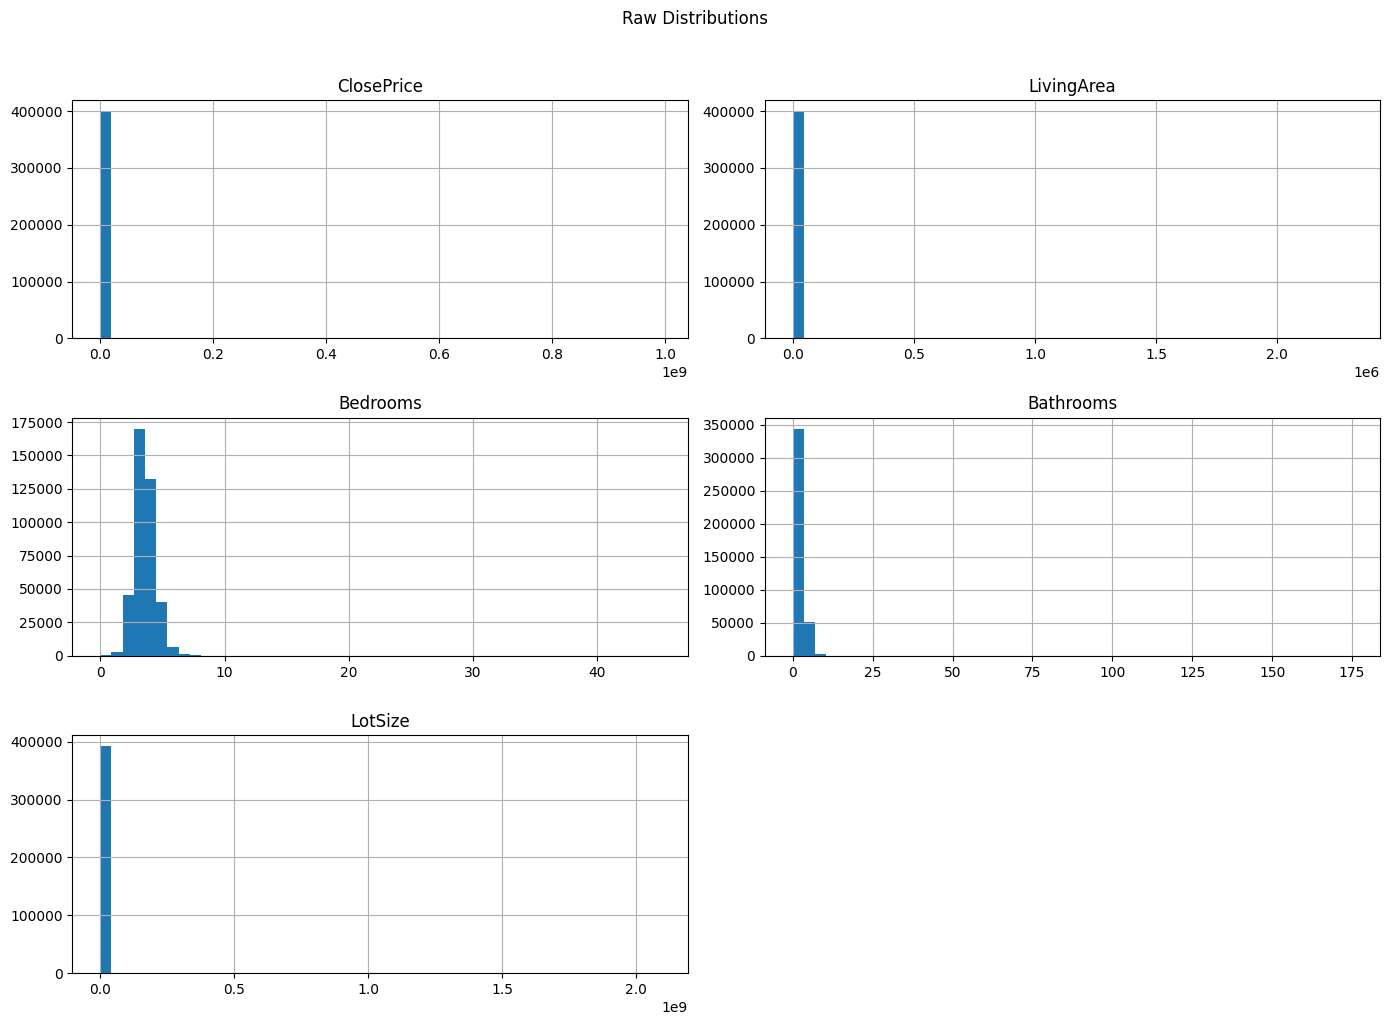

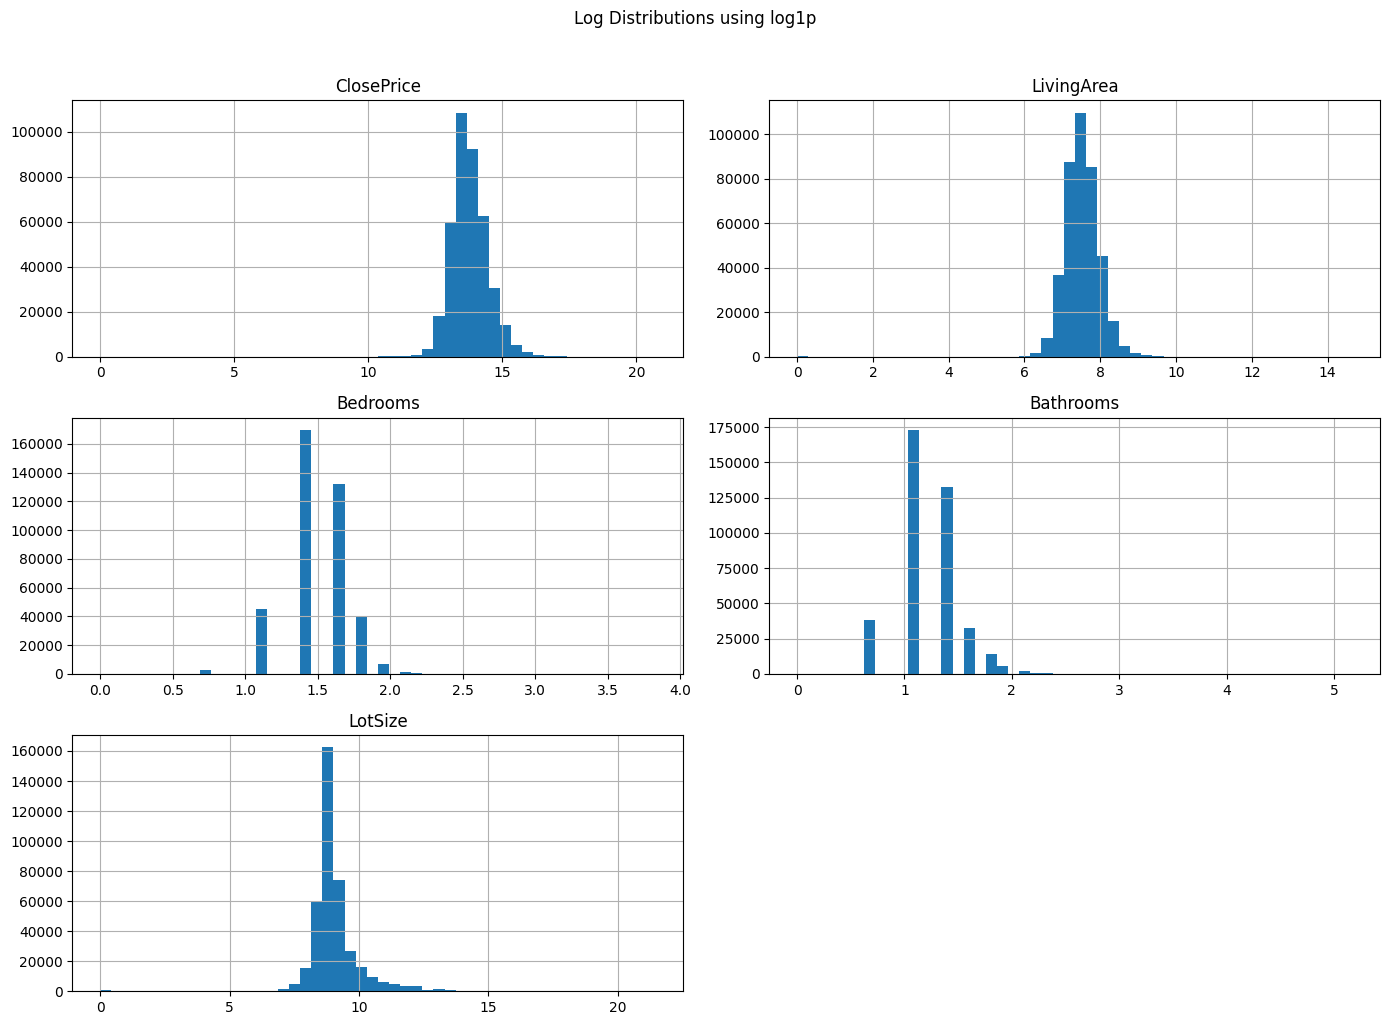

In [18]:
import matplotlib.pyplot as plt

single_family[eda_columns].hist(bins=50, figsize=(14, 10))
plt.suptitle('Raw Distributions', y=1.02)
plt.tight_layout()
plt.show()

log_data = single_family[eda_columns].copy()

for column in eda_columns:
    log_data[column] = log_data[column].where(log_data[column] >= 0)
    log_data[column] = np.log1p(log_data[column])

log_data.hist(bins=50, figsize=(14, 10))
plt.suptitle('Log Distributions using log1p', y=1.02)
plt.tight_layout()
plt.show()

## 11. Quick observations

- `ClosePrice`, `LivingArea`, and `LotSize` are right-skewed.
- `Bedrooms` and `Bathrooms` are count-like variables, so their distributions are more discrete.
- The quantile table and outlier table show large high-end values, especially for `ClosePrice` and `LotSize`.
- For modeling later, it may be useful to consider log transformations for very skewed variables such as `ClosePrice`, `LivingArea`, and `LotSize`.
